In [1]:
# Importamos librerías necesarias.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import RMSprop

import matplotlib.pyplot as plt
import math as mt
import numpy as np

In [2]:
class EDO(Sequential):
    def __init__(self, edo, ci, **kwargs):
        """
        Los parámetros son:
        edo: función que recibe (x, y, dy, ddy) y devuelve el residuo de la EDO.
        ci: función que recibe el modelo y devuelve una lista de residuos de las CI.
        """
        super().__init__(**kwargs)
        # Métrica para registrar la pérdidad en cada época.
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.mse = tf.keras.losses.MeanSquaredError()
        self.edo = edo
        self.ci = ci

    @property
    def metrics(self):
        return [self.loss_tracker]

    def train_step(self, data):
        # data son los puntos del intervalo.
        # El número de puntos muestreados en cada batch.
        batch_size = tf.shape(data)[0]
        min_val = tf.cast(tf.reduce_min(data), tf.float32)
        max_val = tf.cast(tf.reduce_max(data), tf.float32)
        # Muestreamos puntos aleatorios en el intervalo.
        x = tf.random.uniform((batch_size, 1), minval=min_val, maxval=max_val)

        # Cálculo del gradiente y actualización de pesos.
        with tf.GradientTape() as tape:
            with tf.GradientTape(persistent=True) as tape2:
                tape2.watch(x)
                # Primera derivada.
                with tf.GradientTape() as tape1:
                    tape1.watch(x)
                    # Sálida de la red.
                    y_pred = self(x, training=True)
                dy = tape1.gradient(y_pred, x)
            # Segunda derivada.
            ddy = tape2.gradient(dy, x)

            # Residuo de la ecuación diferencial.
            eq_resid = self.edo(x, y_pred, dy, ddy)
            # Residuo de las condiciones iniciales.
            ic_resid = self.ci(self)

            # Función de pérdida.
            loss = self.mse(tf.zeros_like(eq_resid), eq_resid)
            for r in ic_resid:
                loss += self.mse(tf.zeros_like(r), r)

        # Descenso de gradiente.
        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        # Actualizamos métricas.
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

In [3]:
# Definimos las EDO's con sus condiciones iniciales.
# Primera EDO: xy' + y = x^2 cos(x).
def edo_a(x, y, dy, ddy):
  return x*dy + y - x**2*tf.math.cos(x)
# Condición inicial de y(0) = 0.
def ci_a(model):
  # Punto inicial.
    x0 = tf.constant([[0.]], dtype=tf.float32)
    # Salida de la red en x = 0.
    y0 = model(x0)
    # Residuo de CI.
    return [y0 - 0.]

# Segunda EDO: y'' + y = 0.
def edo_b(x, y, dy, ddy):
  return ddy + y
# Condiciones iniciales de y(0)=1, y'(0)=-.5
def ci_b(model):
    x0 = tf.constant([[0.]], dtype=tf.float32)
    y0 = model(x0)
    with tf.GradientTape() as tape:
        tape.watch(x0)
        y0_pred = model(x0)
    dy0 = tape.gradient(y0_pred, x0)
    return [y0 - 1., dy0 - (-0.5)]

In [ ]:
# Aplicamos la capa a la primera EDO.
model_a = EDO(edo_a, ci_a)
# Se agregan capas densas.
model_a.add(Dense(64, activation="tanh", input_shape=(1,)))
model_a.add(Dense(32, activation="tanh"))
# Se agrega una de sálida con una neurona.
model_a.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


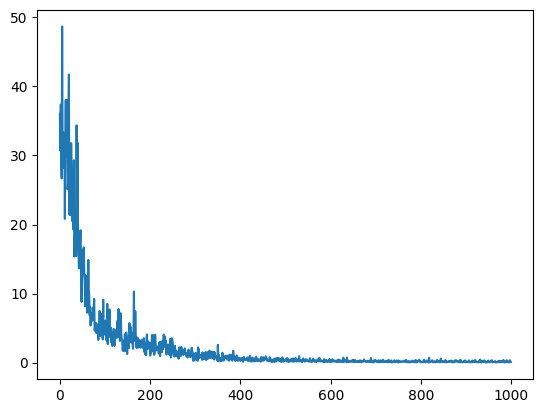

In [ ]:
# Se compila el modelo con RMSprop de optimizador.
model_a.compile(optimizer=RMSprop(learning_rate=0.001),metrics=['loss'])
x = tf.linspace(-5,5,100)
# Entrenamos el modelo y graficamos la pérdida.
history = model_a.fit(x,epochs=1000,verbose=0)
plt.plot(history.history["loss"])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


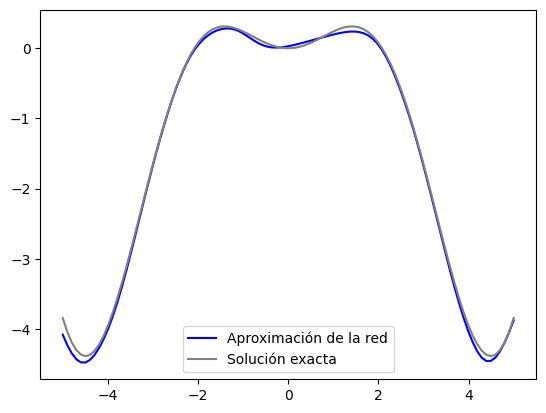

In [ ]:
# Se grafica el rendimiento de la red.
x = tf.linspace(-5,5,100)
a=model_a.predict(x)
plt.plot(x,a,label="Aproximación de la red", color='blue')
# Se coloca la solución a la ec. diferencial.
plt.plot(x,x*tf.math.sin(x) + 2*tf.math.cos(x) - 2/x*tf.math.sin(x),label="Solución exacta", color='gray')
plt.legend()
plt.show()

In [4]:
# Se hace lo mismo con la segunda ecuación diferencial.
model_b = EDO(edo_b, ci_b)
model_b.add(Dense(64, activation="tanh", input_shape=(1,)))
model_b.add(Dense(32, activation="tanh"))
model_b.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


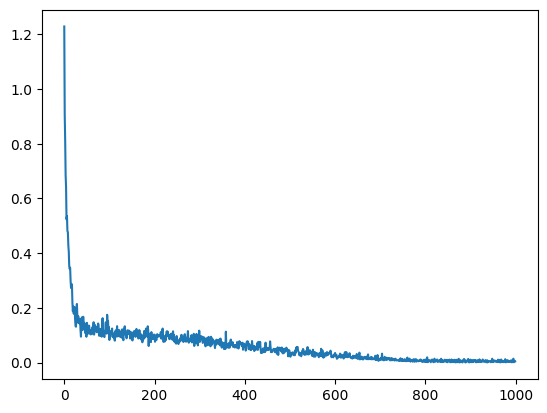

In [5]:
# Se repiten los hiperparámetros.
model_b.compile(optimizer=RMSprop(learning_rate=0.001),metrics=['loss'])
x = tf.linspace(-5,5,100)
history = model_b.fit(x,epochs=1000,verbose=0)
plt.plot(history.history["loss"])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


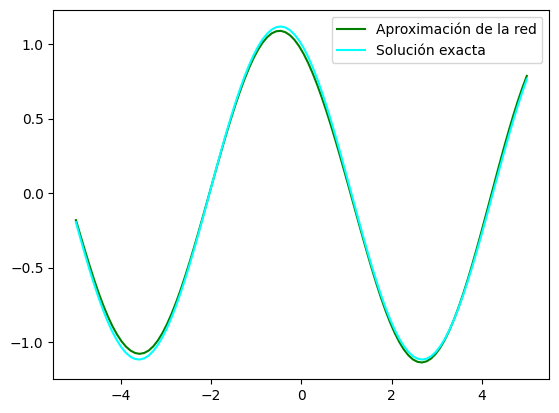

In [6]:
x = tf.linspace(-5,5,100)
b=model_b.predict(x)
plt.plot(x,b,label="Aproximación de la red", color='green')
plt.plot(x,tf.math.cos(x) - .5*tf.math.sin(x),label="Solución exacta", color='cyan')
plt.legend()
plt.show()